In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [3]:
df = pd.read_csv("../data/data_science_job_posts_2025.csv")

print("Dataset carregado com sucesso.")

Dataset carregado com sucesso.


In [4]:
df.head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


In [5]:
df.tail()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
939,data scientist,senior,NaN,company_171,"Bengaluru, Karnataka, India",a day ago,"Armonk, NY, US",Technology,Public,"524,598",€120.29B,"€33,288 - €53,080","['pytorch', 'python', 'sql', 'machine learning..."
940,machine learning engineer,senior,NaN,company_134,"Melbourne, Victoria, Australia",a month ago,"Seattle, WA, US",Retail,Public,"865,456",€838.78B,"€64,290","['amazon', 'machine learning']"
941,data scientist,midlevel,on-site,company_395,"McLean, VA",11 days ago,"McLean, VA, US",Retail,Public,"55,150",€36.29B,"€145,904 - €166,510","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
942,data scientist,midlevel,on-site,company_395,"New York, NY",17 days ago,"McLean, VA, US",Retail,Public,"55,110",€36.34B,"€159,149 - €181,595","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
943,data scientist,senior,on-site,company_844,"San Diego, CA",8 days ago,"Mountain View, CA, US",Technology,Public,"17,040",€95.22B,"€195,486 - €201,926","['r', 'python', 'scala', 'sql', 'machine learn..."


In [6]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 944
Colunas: 13


In [7]:
df.columns.tolist()

['job_title',
 'seniority_level',
 'status',
 'company',
 'location',
 'post_date',
 'headquarter',
 'industry',
 'ownership',
 'company_size',
 'revenue',
 'salary',
 'skills']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_title        941 non-null    str  
 1   seniority_level  884 non-null    str  
 2   status           688 non-null    str  
 3   company          944 non-null    str  
 4   location         942 non-null    str  
 5   post_date        944 non-null    str  
 6   headquarter      944 non-null    str  
 7   industry         944 non-null    str  
 8   ownership        897 non-null    str  
 9   company_size     944 non-null    str  
 10  revenue          929 non-null    str  
 11  salary           944 non-null    str  
 12  skills           944 non-null    str  
dtypes: str(13)
memory usage: 96.0 KB


In [9]:
df.describe()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
count,941,884,688,944,942,944,944,944,897,944,929,944,944
unique,4,4,3,420,431,42,197,8,2,510,312,896,400
top,data scientist,senior,on-site,company_134,"Bengaluru, Karnataka, India",a month ago,"San Francisco, CA, US",Technology,Public,900,Private,"€137,000",[]
freq,856,630,363,30,52,167,91,582,579,18,247,3,201


In [10]:
df.describe(include="object")

/var/folders/qn/5x53vm093yg2q8hn92f2324h0000gn/T/ipykernel_33779/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
count,941,884,688,944,942,944,944,944,897,944,929,944,944
unique,4,4,3,420,431,42,197,8,2,510,312,896,400
top,data scientist,senior,on-site,company_134,"Bengaluru, Karnataka, India",a month ago,"San Francisco, CA, US",Technology,Public,900,Private,"€137,000",[]
freq,856,630,363,30,52,167,91,582,579,18,247,3,201


In [11]:
missing = pd.DataFrame({
    "Quantidade": df.isnull().sum(),
    "Percentual (%)": round(df.isnull().mean() * 100, 2)
})

missing.sort_values(
    by="Percentual (%)",
    ascending=False
)

,Quantidade,Percentual (%)
status,256,27.12
seniority_level,60,6.36
ownership,47,4.98
revenue,15,1.59
job_title,3,0.32
location,2,0.21
company,0,0.00
post_date,0,0.00
headquarter,0,0.00
industry,0,0.00


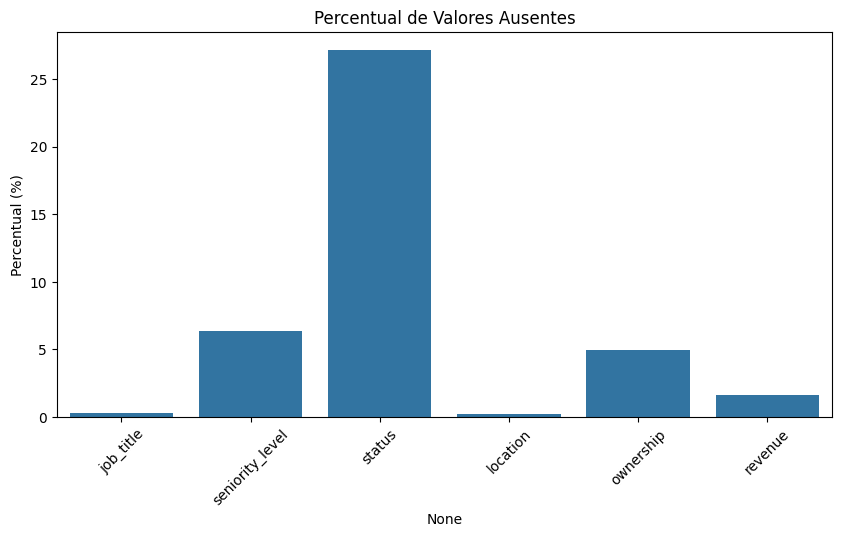

In [12]:
missing = missing[missing["Quantidade"] > 0]

plt.figure(figsize=(10,5))
sns.barplot(
    x=missing.index,
    y=missing["Percentual (%)"]
)

plt.xticks(rotation=45)
plt.title("Percentual de Valores Ausentes")
plt.show()

In [13]:
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


In [14]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].nunique())


job_title
4

seniority_level
4

status
3

company
420

location
431

post_date
42

headquarter
197

industry
8

ownership
2

company_size
510

revenue
312

salary
896

skills
400


In [15]:
df["job_title"].value_counts()

job_title
data scientist               856
machine learning engineer     80
data engineer                  4
data analyst                   1
Name: count, dtype: int64

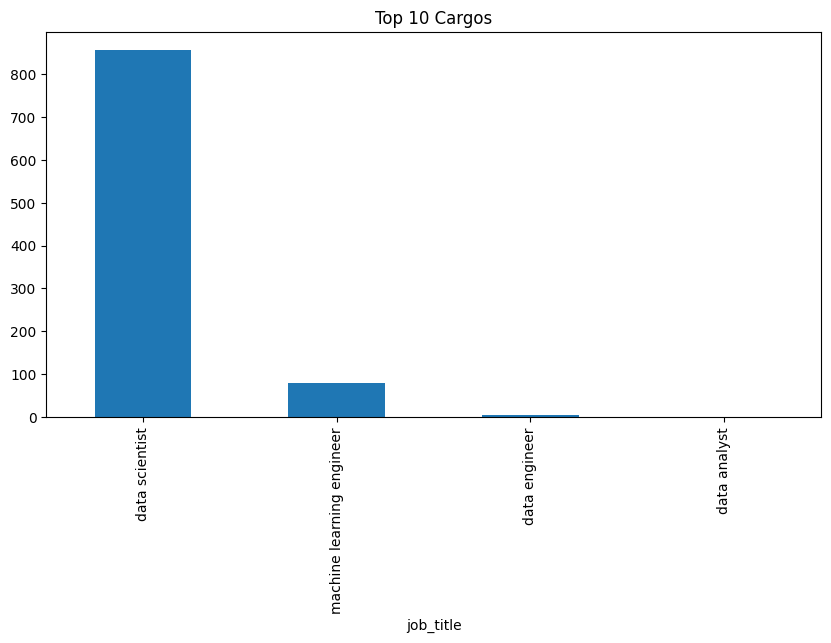

In [16]:
plt.figure(figsize=(10,5))

df["job_title"]\
    .value_counts()\
    .head(10)\
    .plot(kind="bar")

plt.title("Top 10 Cargos")
plt.show()

In [29]:
df["seniority_level"].value_counts()

seniority_level
senior      630
lead        116
midlevel    113
junior       25
Name: count, dtype: int64

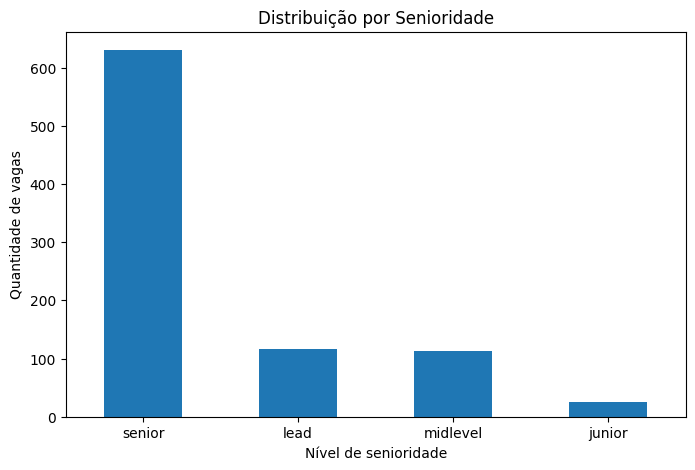

In [30]:
plt.figure(figsize=(8,5))

df["seniority_level"]\
    .value_counts()\
    .plot(kind="bar")

plt.title("Distribuição por Senioridade")
plt.xlabel("Nível de senioridade")
plt.ylabel("Quantidade de vagas")
plt.xticks(rotation=0)
plt.show()

In [31]:
df["status"].value_counts(dropna=False)

status
on-site    363
NaN        256
hybrid     207
remote     118
Name: count, dtype: int64

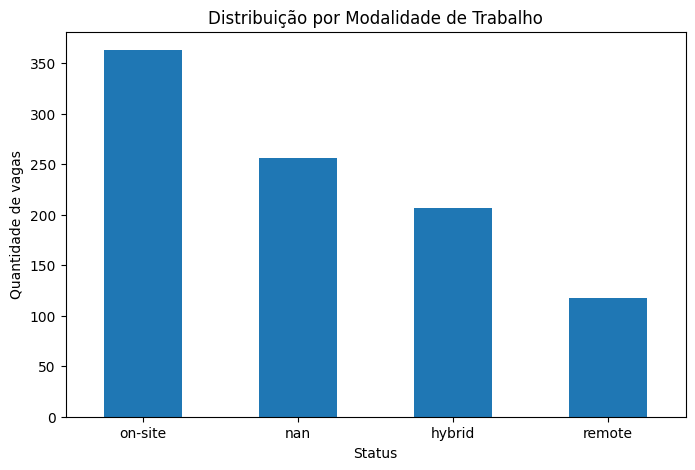

In [32]:
plt.figure(figsize=(8,5))

df["status"]\
    .value_counts(dropna=False)\
    .plot(kind="bar")

plt.title("Distribuição por Modalidade de Trabalho")
plt.xlabel("Status")
plt.ylabel("Quantidade de vagas")
plt.xticks(rotation=0)
plt.show()

In [21]:
df["industry"].value_counts().head(15)

industry
Technology       582
Finance          127
Retail           110
Healthcare        83
Education         19
Energy            12
Manufacturing      7
Logistics          4
Name: count, dtype: int64

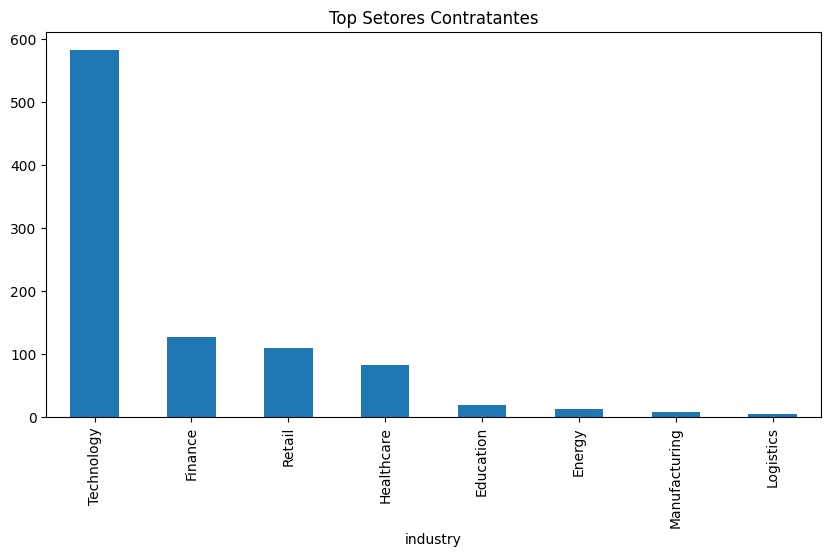

In [22]:
plt.figure(figsize=(10,5))

df["industry"]\
    .value_counts()\
    .head(10)\
    .plot(kind="bar")

plt.title("Top Setores Contratantes")
plt.show()

In [23]:
df["salary"].describe()

count          944
unique         896
top       €137,000
freq             3
Name: salary, dtype: object

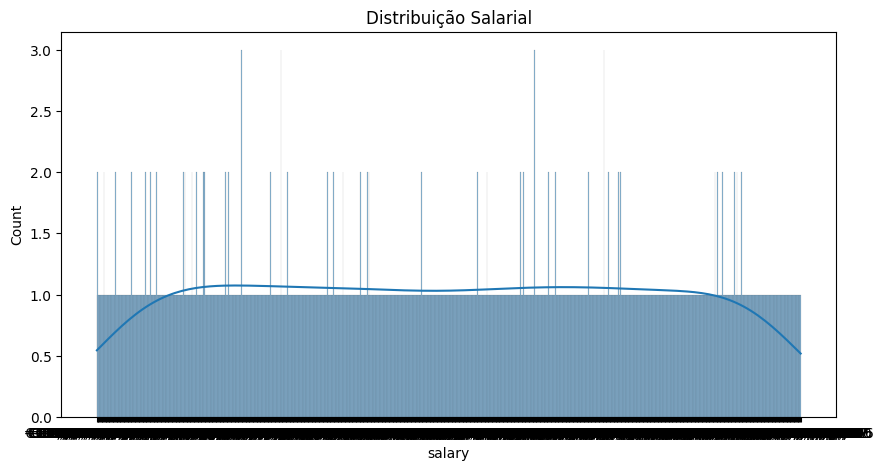

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["salary"],
    bins=30,
    kde=True
)

plt.title("Distribuição Salarial")
plt.show()

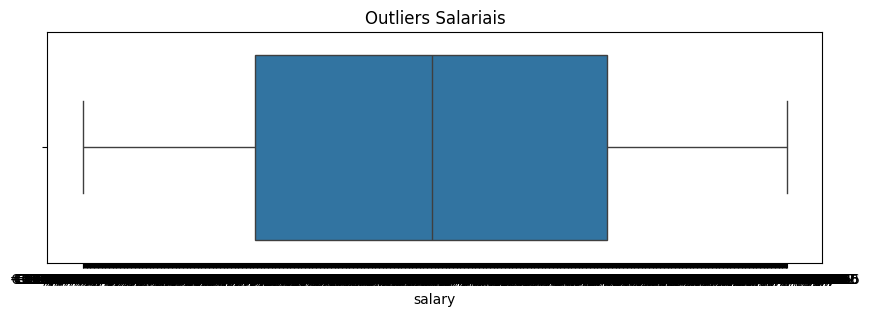

In [25]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["salary"]
)

plt.title("Outliers Salariais")
plt.show()

In [26]:
df["skills"].head()

0    ['spark', 'r', 'python', 'scala', 'machine lea...
1    ['spark', 'r', 'python', 'sql', 'machine learn...
2    ['aws', 'git', 'python', 'docker', 'sql', 'mac...
3                               ['sql', 'r', 'python']
4                                                   []
Name: skills, dtype: str

In [27]:
df["skills"].sample(10)

105                            ['java', 'sql', 'python']
268                          ['pandas', 'sql', 'python']
558    ['python', 'docker', 'kubernetes', 'machine le...
562    ['pytorch', 'r', 'python', 'machine learning',...
763    ['pytorch', 'aws', 'r', 'python', 'docker', 's...
489                ['sql', 'machine learning', 'python']
99     ['pytorch', 'git', 'python', 'machine learning...
774    ['spark', 'r', 'python', 'scala', 'sql', 'mach...
136    ['spark', 'r', 'python', 'scala', 'linux', 'ja...
362    ['pandas', 'numpy', 'pytorch', 'r', 'python', ...
Name: skills, dtype: str

In [28]:
print("="*50)

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
print(f"Duplicados: {df.duplicated().sum()}")

print("\nValores Ausentes:")

print(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

print("="*50)

Linhas: 944
Colunas: 13
Duplicados: 0

Valores Ausentes:
status             256
seniority_level     60
ownership           47
revenue             15
job_title            3
location             2
company              0
post_date            0
headquarter          0
industry             0
company_size         0
salary               0
skills               0
dtype: int64
